# Aim: inspect distribution of EGFR transcript/protein levels across `cytof_init` and `cytof_dynamic` PCA-ed down to top 2 components

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

samples = get_samples("dream_cytof")
petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK", data="dream_cytof"))
del petab_base_files["condition_table"]

cytof_init, cytof_dynamic = [
    load_data(
        contextualization=context,
        samples=samples,
        features=None,
        **petab_base_files,
    )[0] for context in ["cytof_init", "cytof_dynamic"]
]

## Get transcript and protein levels (also included ERBB2)

In [2]:
transcriptomics, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
tegfr = transcriptomics["EGFR"]
tegfr -= tegfr.mean()
terbb2 = transcriptomics["ERBB2"]
terbb2 -= terbb2.mean()
del transcriptomics

proteomics, _, _ = load_data(
    contextualization="proteomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
pegfr = proteomics["EGFR"]
pegfr -= pegfr.mean()
perbb2 = proteomics["ERBB2"]
perbb2 -= perbb2.mean()
del proteomics

## PCA and annotate

In [3]:
def get_pca_df(df, n_components=2, impute=False):
    pca = PCA(n_components=n_components)
    if impute:
        values = pca.fit_transform(KNNImputer().fit_transform(df))
        index = df.index
    else:
        values = pca.fit_transform(df.dropna())
        index = df.dropna().index
    pca_df = pd.DataFrame(
        values,
        columns=[f"PCA{i+1}" for i in range(n_components)],
        index=index
    )
    return pca_df


def add_egfr_annotations(df, tegfr, pegfr, terbb2, perbb2):
    df["tEGFR"] = tegfr.loc[df.index]
    df["pEGFR"] = pegfr.loc[df.index]
    df["tERBB2"] = terbb2.loc[df.index]
    df["pERBB2"] = perbb2.loc[df.index]
    return df

cytof_init_pca = add_egfr_annotations(get_pca_df(cytof_init), tegfr, pegfr, terbb2, perbb2)
cytof_dynamic_pca = add_egfr_annotations(get_pca_df(cytof_dynamic), tegfr, pegfr, terbb2, perbb2)

## Plot results

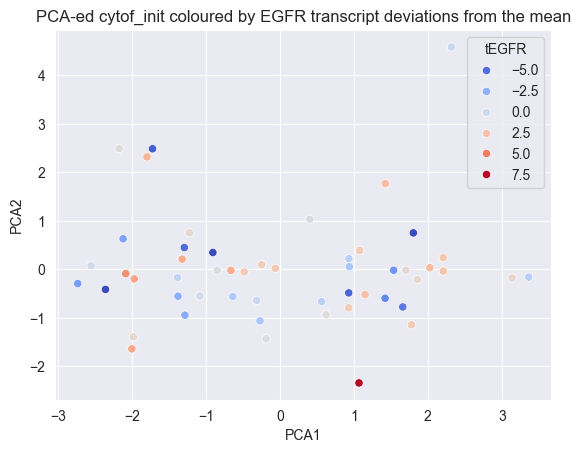

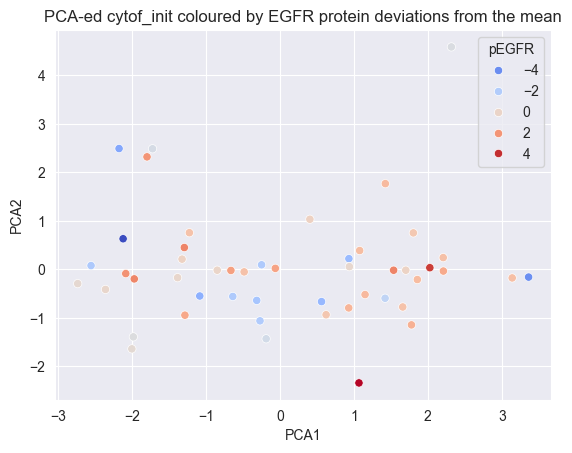

In [4]:
for marker_type in ["transcript", "protein"]:
    sns.scatterplot(
        cytof_init_pca,
        x="PCA1",
        y="PCA2",
        hue=f"{marker_type[0]}EGFR",
        palette="coolwarm"
    )
    plt.title(f"PCA-ed cytof_init coloured by EGFR {marker_type} deviations from the mean")
    plt.show()

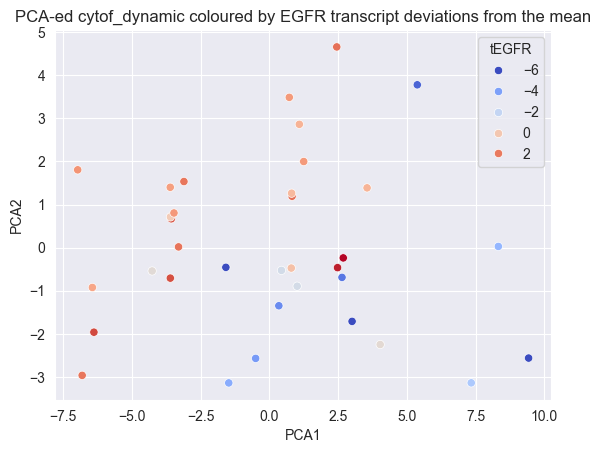

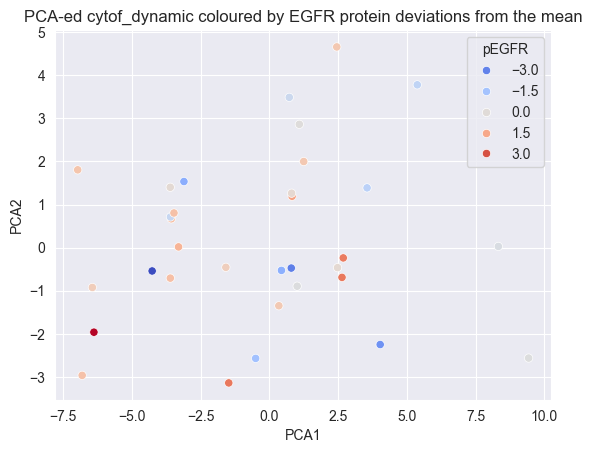

In [5]:
for marker_type in ["transcript", "protein"]:
    sns.scatterplot(
        cytof_dynamic_pca,
        x="PCA1",
        y="PCA2",
        hue=f"{marker_type[0]}EGFR",
        palette="coolwarm"
    )
    plt.title(f"PCA-ed cytof_dynamic coloured by EGFR {marker_type} deviations from the mean")
    plt.show()

### We can check the linear decision boundary with a simple SVM classifier

In [6]:
from sklearn.svm import SVC

tegfr_binarised = tegfr > 0

svc = SVC(kernel="linear")
svc.fit(cytof_dynamic_pca[["PCA1", "PCA2"]].values, tegfr_binarised.loc[cytof_dynamic_pca.index])
svc.score(cytof_dynamic_pca[["PCA1", "PCA2"]].values, tegfr_binarised.loc[cytof_dynamic_pca.index])

0.8

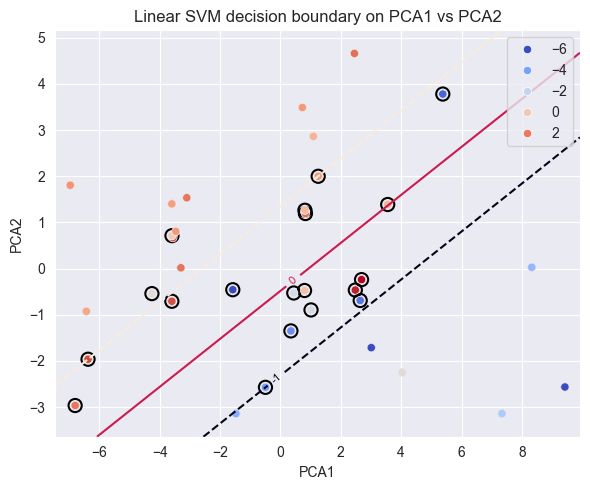

In [7]:
import numpy as np

# Data (already used for fitting)
X = cytof_dynamic_pca[["PCA1", "PCA2"]].values
y = tegfr_binarised.loc[cytof_dynamic_pca.index].values

# Grid for contours
pad = 0.5
x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

# Decision function over the grid
Z = svc.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))

# Scatter of points (color by class)
plt.scatter(X[:, 0], X[:, 1], c=y, s=25, edgecolor="k", alpha=0.8)

# Decision boundary (0) and margins (-1, +1)
CS = plt.contour(xx, yy, Z, levels=[-1, 0, 1],
                 linestyles=["--", "-", "--"], linewidths=1.5)
plt.clabel(CS, inline=True, fontsize=8, fmt={-1: "-1", 0: "0", 1: "+1"})

# Support vectors
plt.scatter(
    svc.support_vectors_[:, 0],
    svc.support_vectors_[:, 1],
    s=90,
    facecolors="none",
    edgecolors="k",
    linewidths=1.5
)

# PCA-ed data coloured by tEGFR
sns.scatterplot(
    cytof_dynamic_pca,
    x="PCA1",
    y="PCA2",
    hue="tEGFR",
    palette="coolwarm"
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Linear SVM decision boundary on PCA1 vs PCA2")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

Not really interesting: looking at ERBB2

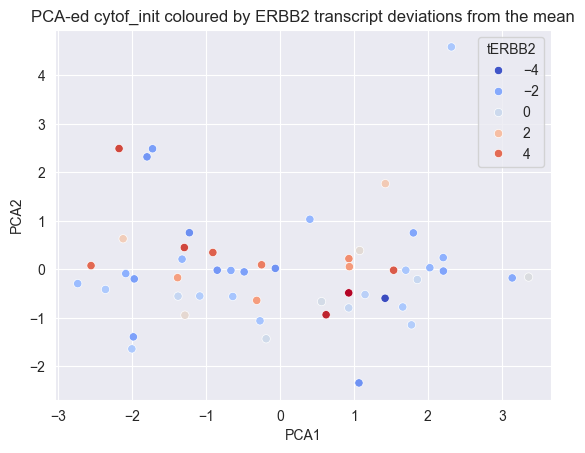

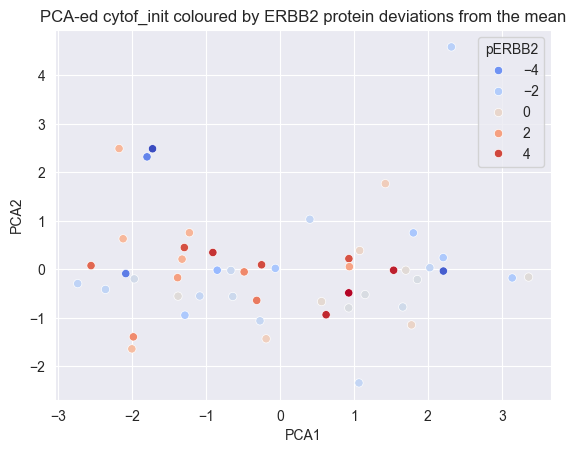

In [8]:
for marker_type in ["transcript", "protein"]:
    sns.scatterplot(
        cytof_init_pca,
        x="PCA1",
        y="PCA2",
        hue=f"{marker_type[0]}ERBB2",
        palette="coolwarm"
    )
    plt.title(f"PCA-ed cytof_init coloured by ERBB2 {marker_type} deviations from the mean")
    plt.show()

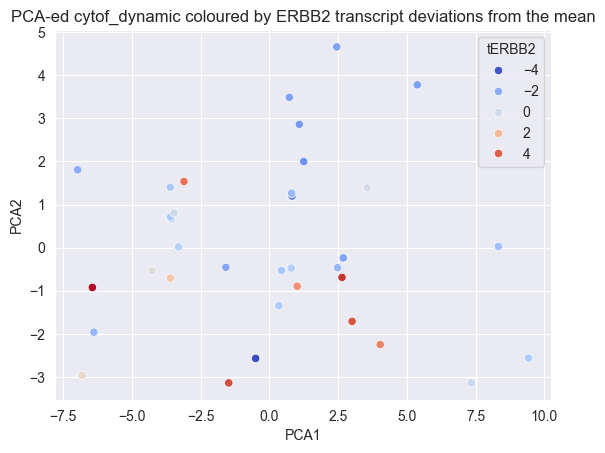

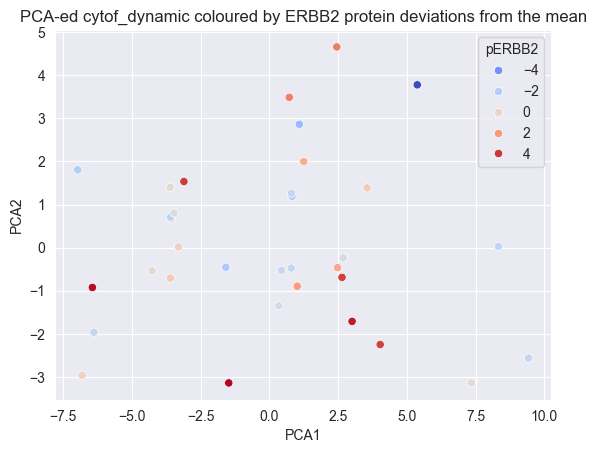

In [9]:
for marker_type in ["transcript", "protein"]:
    sns.scatterplot(
        cytof_dynamic_pca,
        x="PCA1",
        y="PCA2",
        hue=f"{marker_type[0]}ERBB2",
        palette="coolwarm"
    )
    plt.title(f"PCA-ed cytof_dynamic coloured by ERBB2 {marker_type} deviations from the mean")
    plt.show()

## Caveat: if we impute missing data in `cytof_dynamic`, we pretty much lose the EGFR trend above - imputation is really not working fine!

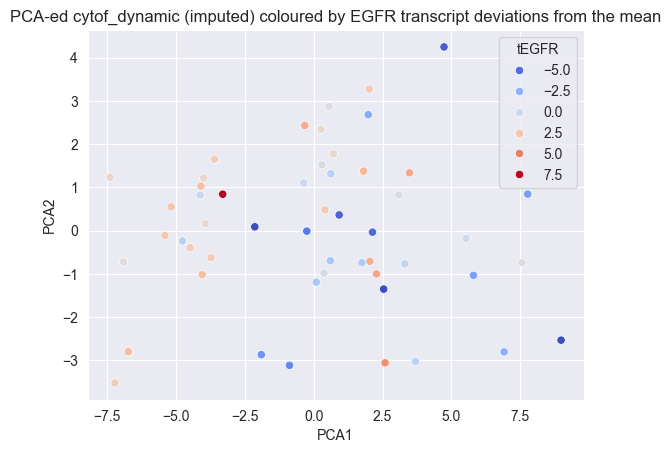

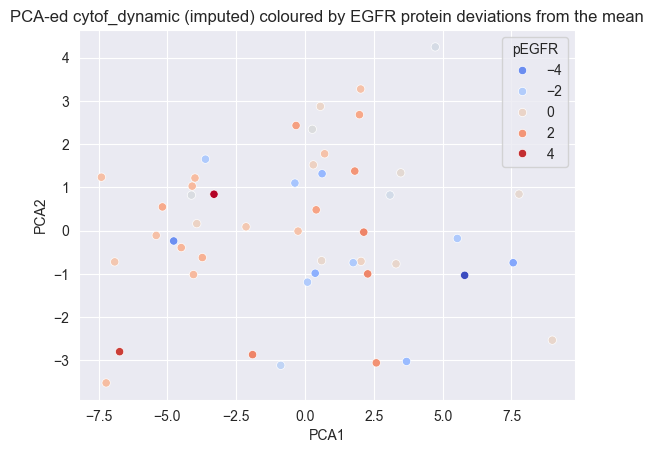

In [10]:
cytof_dynamic_pca_imputed = add_egfr_annotations(get_pca_df(cytof_dynamic, impute=True), tegfr, pegfr, terbb2, perbb2)
for marker_type in ["transcript", "protein"]:
    sns.scatterplot(
        cytof_dynamic_pca_imputed,
        x="PCA1",
        y="PCA2",
        hue=f"{marker_type[0]}EGFR",
        palette="coolwarm"
    )
    plt.title(f"PCA-ed cytof_dynamic (imputed) coloured by EGFR {marker_type} deviations from the mean")
    plt.show()